In [12]:
import PKA_Sleep as PKA
import numpy as np
import os
import pandas as pd

In [32]:
##These parameteres won't change between brain regions
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 40
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = False
seperate_acqs = False
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
these_transitions = ['NREM-Wake','REM-Wake', 'Microarousals','Wake-NREM','NREM-REM']

window = [50,150]
intensity = False
diff_wake = False
shuffled = True
fig_dict = False
long_short_wake = True
long_short_NREM = True
NREM_cutoff = 70
wake_cutoff = 100
just_dictionary = False
axes_width = 0.3
region_colors = {'Dorsal CA1':'#ff9408',
                'Motor Cortex':'#9d0085',
                'Visual Cortex': '#0089f4',
                'mPFC': '#00b47c'}

In [33]:
data = {'Dorsal CA1': {'Experiments': ['ltFLiPAKARmemEEGEMG0005',
   'ltFLiPAKARmemEEGEMG0006',
   'ltFLiPAKARmemEEGEMG0007',
   'ltFLiPAKARmemEEGEMG0008',
   'ltFLiPAKARmemEEGEMG0011',
   'dgFLiPmemAKAREEGEMG0001',
   'dgFLiPmemAKAREEGEMG0002',
   'dgFLiPmemAKAREEGEMG0004',
   'dgFLiPmemAKAREEGEMG0006',
   'dgFLiPmemAKAREEGEMG0007'],
  'Animals': ['3707-3',
   '3707-3',
   '3971',
   '3971',
   '3848-t3',
   '3971',
   '3707-3',
   '3848-t3',
   '3971',
   '3707-3']},
 'Motor Cortex': {'Experiments': ['ltFLiPAKARmemEEGEMG0061',
   'ltFLiPAKARmemEEGEMG0078',
   'ltFLiPAKARmemEEGEMG0089'],
  'Animals': ['4512', '4873', '4772']},
 'Visual Cortex': {'Experiments': ['ltFLiPAKARmemEEGEMG0060',
   'ltFLiPAKARmemEEGEMG0070',
   'ltFLiPAKARmemEEGEMG0081'],
  'Animals': ['4514', '4518', '4871']},
 'mPFC': {'Experiments': ['ltFLiPAKARmemEEGEMG0009',
   'ltFLiPAKARmemEEGEMG0010',
   'dgFLiPmemAKAREEGEMG0003',
   'dgFLiPmemAKAREEGEMG0008',
   'ltFLiPAKARmemEEGEMG0036',
   'ltFLiPAKARmemEEGEMG0043',
   'kgFLiPAKAREEGEMG0009',
   'ltFLiPAKARmemEEGEMG0055',
   'ltFLiPAKARmemEEGEMG0068',
   'ltFLiPAKARmemEEGEMG0072',
   'ltFLiPAKARmemEEGEMG0085',
   'ltFLiPAKARmemEEGEMG0090-1',
   'ltFLiPAKARmemEEGEMG0094',
   'ltFLiPAKARmemEEGEMG0097-1',
   'ltFLiPAKARmemEEGEMG0098-1',
   'ltFLiPAKARmemEEGEMG0099-1',
   'ltFLiPAKARmemEEGEMG0099-2',
   'ltFLiPAKARmemEEGEMG0100-1',
   'ltFLiPAKARmemEEGEMG0101-1',
   'ltFLiPAKARmemEEGEMG0102-1',
   'ltFLiPAKARmemEEGEMG0103-1',
   'kgFLiPAKAREEGEMG0018',
   'kgFLiPAKAREEGEMG0019',
   'kgFLiPAKAREEGEMG0020'],
  'Animals': ['3825',
   '3825',
   '3825',
   '3825',
   '4346-t5-7',
   '4346-t5-7',
   '4507',
   '4502',
   '4507',
   '4610',
   '4713',
   '4769',
   '4775',
   '5782',
   '5007',
   '5075',
   '5075',
   '5078',
   '5046',
   '5047',
   '5076',
   '5582',
   '5583',
   '5577']}}

In [34]:
# savedir = False
raw_lifetime = False # True/False (True: Plotting raw or ZScored; False: zeroed lifetime)
if raw_lifetime:
    raw_str = 'raw'
else:
    raw_str = ''
zscore = False #True/False (True: plotting zscore)
if zscore:
    zscore_str = 'ZScore'
else:
    zscore_str = ''

figure_dir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Manuscripts/PKASleep/PKASleep_Figures/Fig2_MultiBrainRegion/'
cre_line = 'CaMKII'
delivery_method = 'ICI'
transition_types = 'alltrans'
if filter_bounds == [None, None]:
    filter_status = 'nofilter'
else:
    filter_status = str(filter_bounds[0])+'-'+str(filter_bounds[1])
fig_ext = '.ps'
fns = [cre_line+'_'+delivery_method+'_'+experimental_sensor+'_'+r.replace(' ', '')+'_'+transition_types+'_'+filter_status+raw_str+zscore_str+fig_ext 
       for r in list(region_colors.keys())]
savedirs = [os.path.join(figure_dir, fn) for fn in fns]

In [35]:
df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [[os.path.join(parent_data_directory, e) for e in data[r]['Experiments']] for r in data.keys()]
baseline_idxs = [[(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in data[r]['Experiments']]] for r in data.keys()]
excluded_acqs = [PKA.choose_excluded_acqs(raw_datadirs[r], first_acqs = 3, specific_acqs = False, pull_baseline = True, 
                                          baseline_idxs = baseline_idxs[r]) for r in range(len(raw_datadirs))]

FLP_classes_dicts = {r:PKA.build_classes(data[r]['Experiments'], data[r]['Animals'], epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = True,p2 = True, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                       exclude_acqs = e) for r,e in zip(list(data.keys()),excluded_acqs)}

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_2740/2683037731.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [[(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

Working on ltFLiPAKARmemEEGEMG0005...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0006...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0007...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0008...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0011...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0001...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0002...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0004...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0006...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0007...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
['NREM-Wake', 'NREM-Wake Long', 'NREM-Wake Short']


Which of the above conditions do you want to plot? NREM-Wake


['Wake-NREM', 'Wake-NREM Long', 'Wake-NREM Short']


Which of the above conditions do you want to plot? Wake-NREM Long


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


...

Working on ltFLiPAKARmemEEGEMG0009...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0010...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0003...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on dgFLiPmemAKAREEGEMG0008...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0036...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0043...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on kgFLiPAKAREEGEMG0009...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0055...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0068...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0072...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on ltFLiPAKARmemEEGEMG0085...
NREM-Wake
REM-Wake
Microarousals
Wake-NREM
NREM-REM
Working on lt

Which of the above conditions do you want to plot? NREM-Wake


['Wake-NREM', 'Wake-NREM Long', 'Wake-NREM Short']


Which of the above conditions do you want to plot? Wake-NREM Long


/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:740: RuntimeWarning: Mean of empty slice
  all_dicts[a]['Average ' + data_key] = {g: {s: average_function(np.concatenate(all_dicts[a][data_key][g][s], axis = 0), axis = 0)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


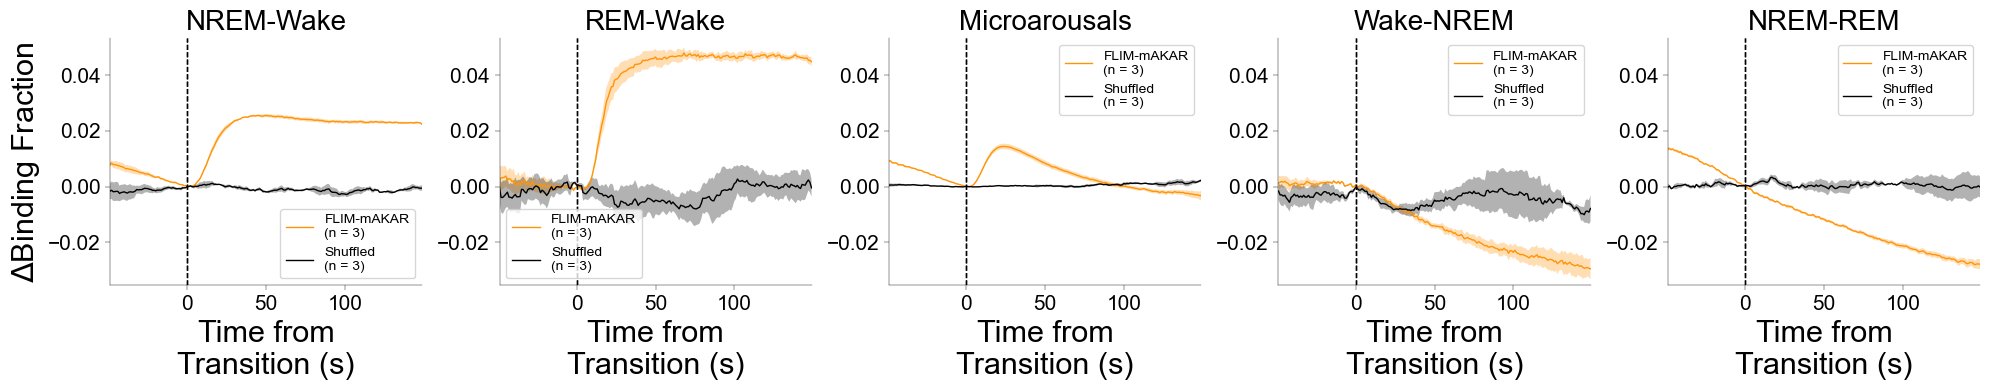

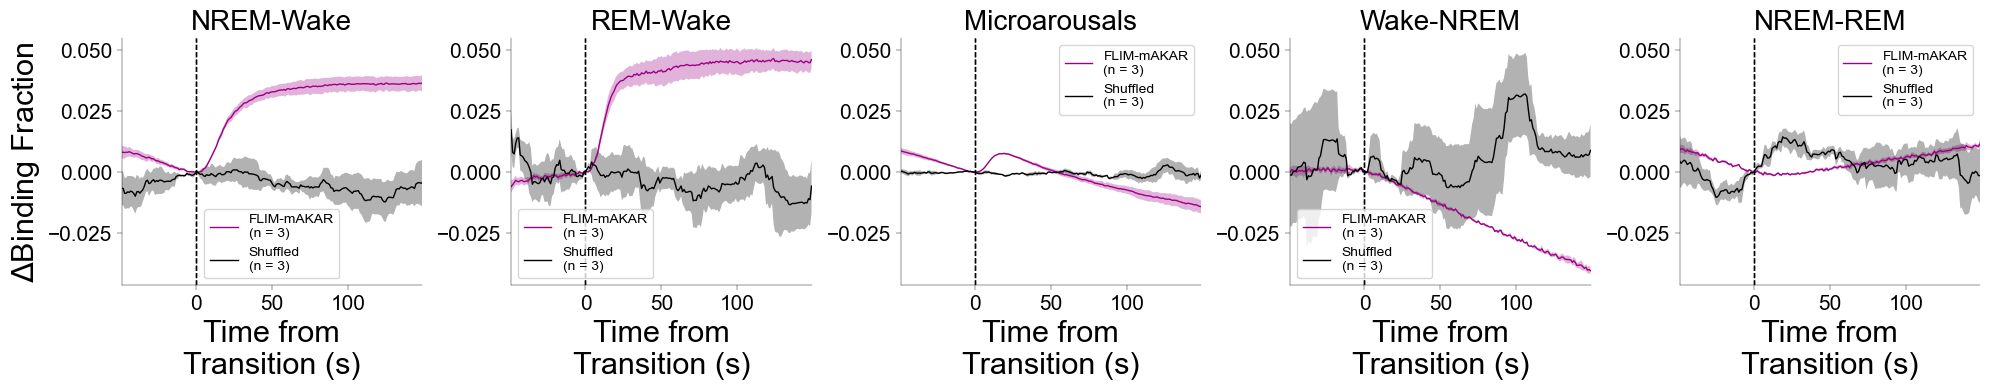

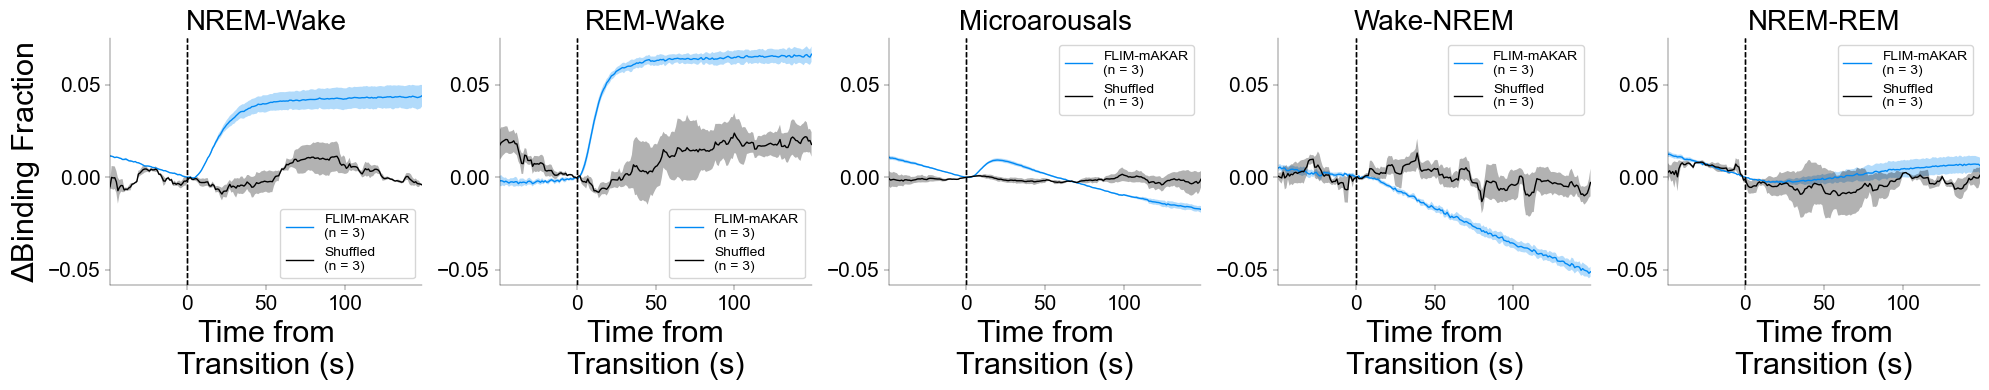

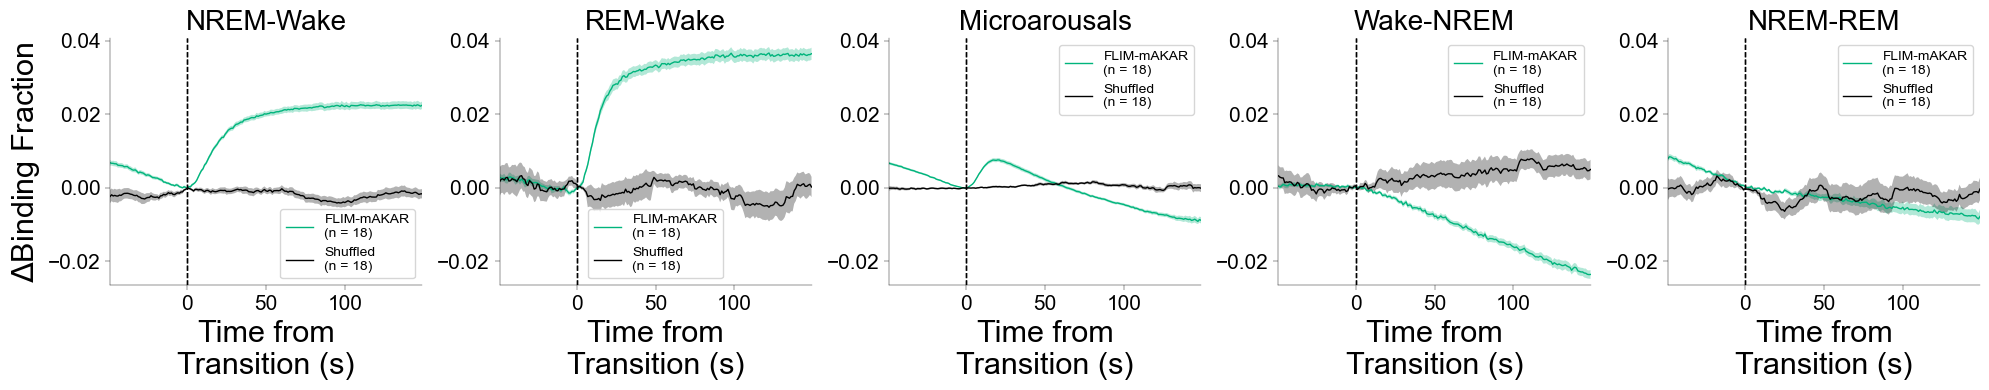

In [36]:
lifetime_dicts = {}
fig_dict = False
shuffled = True
for i,r in enumerate(data.keys()):
    fig_dict = False
    FLP_classes_dict = FLP_classes_dicts[r]
    color_dict = {k: region_colors[r] for k in these_transitions}
    fig_dict, lifetime_dict = PKA.transition_triggered_lifetime(FLP_classes_dict['Experiment Classes'], FLP_classes_dict['Experiment Names'], FLP_classes_dict['Animal Names'], 
                                                        window = window, savedir = savedirs[i], these_transitions = these_transitions,
                                                        intensity = intensity, diff_wake = diff_wake, shuffled = shuffled, 
                                                        fig_dict = fig_dict, color_dict = color_dict, long_short_wake = long_short_wake, 
                                                        long_short_NREM = long_short_NREM, NREM_cutoff = NREM_cutoff, 
                                                        wake_cutoff = wake_cutoff, raw_lifetime = raw_lifetime, 
                                                        just_dictionary = just_dictionary, axes_width = axes_width, zscore = zscore)
    for a in fig_dict['Lifetime']['Axes']:
        a.legend()
    fig_dict['Lifetime']['Figure'].savefig(savedirs[i])
    lifetime_dicts[r] = lifetime_dict

In [37]:
import importlib
importlib.reload(PKA.FLPstats)
importlib.reload(PKA)
#Run the stats
these_outcomes = ['NREM-Wake', 'REM-Wake', 'Microarousals', 'Wake-NREM', 'NREM-REM']
amp_windows = {'NREM-Wake': [50, 75],
               'REM-Wake': [50, 75],
               'Microarousals': [10,30], 
               'Wake-NREM':[75,100], 
               'NREM-REM':[75,100]}
slope = False
sleep_slope_win = [30,100]
wake_slope_win = [0,20]
quant_dicts = {k:PKA.transition_triggered_quant(lifetime_dicts[k], amp_windows, slope = slope) for k in region_colors.keys()}
all_results = {}
for r in quant_dicts.keys():
    mouseID = [str(quant_dicts[r]['Mouse ID'][i]) for i in range(len(quant_dicts[r]['Mouse ID']))]
    grouped_expnames = [quant_dicts[r]['Experiment Name'],quant_dicts[r]['Experiment Name']]
    grouped_mouseIDs = [mouseID, mouseID]
    group_labels = [experimental_sensor, 'Shuffled']

    data_categories = quant_dicts[r]['LFT Quant']['FLIM-mAKAR'].keys()
    # for c in data_categories:
    #     grouped_data = [quant_dicts[r]['LFT Quant'][k][c] for k in ['Shuffled', experimental_sensor]]
    #     data_df, standard_result, robust_result, pvals = PKA.nested_analysis_stats(grouped_data, grouped_expnames, 
    #                                                                                grouped_mouseIDs, group_labels)
    #     all_pvals[r][c] = pvals
    # import importlib
    # importlib.reload(PKA.FLPstats)
    # importlib.reload(PKA)
    all_results[r] = {}
    perm_flag = True
    if r == 'mPFC':
        perm_flag = False
    for c in data_categories:
        grouped_data = [
            quant_dicts[r]['LFT Quant'][experimental_sensor][c],
            quant_dicts[r]['LFT Quant']['Shuffled'][c]
        ]
        stage1_df, perm_result, welch_result = PKA.nested_analysis_stats_v2(
            grouped_data, grouped_expnames, grouped_mouseIDs, group_labels, perm_flag = perm_flag, paired=True)
        all_results[r][c] = {
            'stage1': stage1_df,
            'perm': perm_result,
            'welch': welch_result
        }

Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals


/Users/lizzie/Desktop/Remote_Git/Chen_Lab/PKA_Sleep/PKA_Sleep/genPKA_Dynamics.py:522: RuntimeWarning: Mean of empty slice
  quant.append(np.nanmean(l[averaging_window]))


Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Working on NREM-Wake
Working on REM-Wake
Working on Microarousals
Working on Wake-NREM
Working on NREM-REM
Stage 1: Computing robust subject-level means using HuberT...
  Processed 6 subject-group combinations
  Observations with downweighted data: 0

=== Stage 1: per-animal robust means ===
Mouse_ID      Group  robust_mean  robust_se  n_obs
  3707-3 FLIM-mAKAR     0.024446   0.001295    110
  3707-3   Shuffled    -0.000865   0.002365    110
    3971 FLIM-mAKAR     0.025061   0.001400     86
    3971   Shuffled    -0.000191   0.002441     86
 3848-t3 FLIM-mAKAR     0.023664   0.001619     89
 3848-t3   Shuffled    -0.002289   0.002365     89

=== Stage 2 (PRIMARY): sign permutation, 8 arrangements ===
  Mean diff (FLIM-mAKAR - Shuffled

In [38]:
region = 'Visual Cortex'
# transitions = list(all_results[region].keys())
transitions = ['Wake-NREM', 'NREM-REM', 'NREM-Wake', 'REM-Wake', 'Microarousals']
for t in transitions:
    print(t + ':' + str(all_results[region][t]['welch']['p_t']))

Wake-NREM:0.06974625896518652
NREM-REM:0.5535169847857035
NREM-Wake:0.010620730548079365
REM-Wake:0.0427237789761589
Microarousals:0.027372982195887356


In [26]:
all_results[region]['Wake-NREM']

{'stage1':   Mouse_ID       Group  robust_mean  robust_se  n_obs  mean_weight
 0     4512  FLIM-mAKAR    -0.025239   0.002902      5     0.930655
 1     4512    Shuffled     0.004243   0.009201      5     0.745462
 2     4873  FLIM-mAKAR    -0.023668   0.002750      4     1.000000
 3     4873    Shuffled     0.011969   0.017972      4     1.000000
 4     4772  FLIM-mAKAR    -0.024054   0.001572     15     0.970518
 5     4772    Shuffled    -0.019222   0.008715     15     0.955554,
 'perm': {'observed_mean_diff': np.float64(-0.023316777600159322),
  'p_perm': np.float64(0.25),
  'n_arrangements': 8,
  'min_possible_p': 0.25,
  'all_stats': array([ 0.02331678, -0.00044092,  0.02009568, -0.00366201,  0.00366201,
         -0.02009568,  0.00044092, -0.02331678])},
 'welch': {'t': np.float64(-2.4774061225740995),
  'df': 2,
  'p_t': np.float64(0.13153842251449507),
  'cohens_d': np.float64(-1.4303310917601832),
  'effect_size_label': "Cohen's dz (paired)"}}